# #1 Data Cleaning & Some Basic EDA

# Importing & Understanding the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
campaign_data = pd.read_csv("marketing_campaign.csv")
campaign_data.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,1/1/2019,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30
1,1/2/2019,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05
2,1/3/2019,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23
3,1/4/2019,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86
4,1/5/2019,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40


In [3]:
campaign_data.shape

(365, 17)

### Initial Data Overview

The campaign_data DataFrame contains 365 rows, with each row representing a single day in the year 2019. The dataset includes 17 columns in total:

- 1 Date column
- 8 columns related to Facebook campaign performance
- 8 columns related to AdWords campaign performance

These columns capture daily marketing metrics such as ad spend, clicks, conversions, cost-per-click and conversion rates for the two advertising platforms.

Detailed description of each column in the dataset is as follows:


| Column Name | Description |
| :--- | :--- |
| Date | The date corresponding to each row of campaign data, ranging from January 1st 2019 to December 31st 2019. |
| Ad Views | The number of times the ad was viewed. |
| Ad Clicks | The number of clicks received on the ad. |
| Ad Conversions | The number of conversions resulting from the ad. |
| Cost per Ad (\$) | The cost associated with running the ad campaign. |
| Click-Through Rate (CTR) (%) | The ratio of clicks to views, indicating the effectiveness of the ad in generating clicks. |
| Conversion Rate (%) | The ratio of conversions to clicks, reflecting the effectiveness of the ad in driving desired actions. |
| Cost per Click (CPC) (\$) | The average cost incurred per click on the ad. |

In [4]:
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             365 non-null    object
 1   Facebook Ad Campaign                             365 non-null    object
 2   Facebook Ad Views                                365 non-null    int64 
 3   Facebook Ad Clicks                               365 non-null    int64 
 4   Facebook Ad Conversions                          365 non-null    int64 
 5   Cost per Facebook Ad                             365 non-null    object
 6   Facebook Click-Through Rate (Clicks / View)      365 non-null    object
 7   Facebook Conversion Rate (Conversions / Clicks)  365 non-null    object
 8   Facebook Cost per Click (Ad Cost / Clicks)       365 non-null    object
 9   AdWords Ad Campaign                        

### Data Quality Observations

A preliminary inspection shows that no missing values are present in the dataset.

1. Incorrect Data Types:
    - The Date column is currently stored as an object and needs to be converted to datetime format.
    - Several numeric fields related to cost, clicks and conversions are incorrectly stored as objects and should be converted to float for accurate analysis.

2. Column Naming Consistency:
    - Column names will be converted to snake_case to improve readability and make them easier to reference in code.  

3. Formatting Characters in Numeric Columns:
    - Some columns contain formatting symbols such as $ and \%, which must be removed before converting the columns to numeric data types.  

These cleaning steps will ensure the dataset is properly formatted and ready for downstream SQL analysis, statistical testing, and visualization.

# Data Cleaning

In [5]:
# formatting Date column to correct data type of datetime:
campaign_data['Date'] = pd.to_datetime(campaign_data['Date'])

In [6]:
# renaming columns to snake_case:

# making all lower case
campaign_data.columns = campaign_data.columns.str.lower()

# replacing space with underscore
campaign_data.columns = campaign_data.columns.str.replace(' ', '_')

# custom renaming certain facebook columns
campaign_data = campaign_data.rename(columns={'facebook_click-through_rate_(clicks_/_view)': 'facebook_click_through_rate', 'facebook_conversion_rate_(conversions_/_clicks)': 'facebook_conversion_rate', 'facebook_cost_per_click_(ad_cost_/_clicks)': 'facebook_cost_per_click'})

# custom renaming certain adwords columns
campaign_data = campaign_data.rename(columns={'adwords_click-through_rate_(clicks_/_view)': 'adwords_click_through_rate', 'adwords_conversion_rate_(conversions_/_click)': 'adwords_conversion_rate', 'adwords_cost_per_click_(ad_cost_/_clicks)': 'adwords_cost_per_click'})

In [7]:
# rechecking column names
campaign_data.columns

Index(['date', 'facebook_ad_campaign', 'facebook_ad_views',
       'facebook_ad_clicks', 'facebook_ad_conversions', 'cost_per_facebook_ad',
       'facebook_click_through_rate', 'facebook_conversion_rate',
       'facebook_cost_per_click', 'adwords_ad_campaign', 'adwords_ad_views',
       'adwords_ad_clicks', 'adwords_ad_conversions', 'cost_per_adwords_ad',
       'adwords_click_through_rate', 'adwords_conversion_rate',
       'adwords_cost_per_click'],
      dtype='object')

In [7]:
# removing $ and % signs and storing values as float for necessary columns:

# for facebook data
campaign_data['cost_per_facebook_ad'] = campaign_data['cost_per_facebook_ad'].apply(lambda x: float(x[1:]))
campaign_data['facebook_click_through_rate'] = campaign_data['facebook_click_through_rate'].apply(lambda x: float(x[:-1]))
campaign_data['facebook_conversion_rate'] = campaign_data['facebook_conversion_rate'].apply(lambda x: float(x[:-1]))
campaign_data['facebook_cost_per_click'] = campaign_data['facebook_cost_per_click'].apply(lambda x: float(x[1:]))

# for adwords data
campaign_data['cost_per_adwords_ad'] = campaign_data['cost_per_adwords_ad'].apply(lambda x: float(x[1:]))
campaign_data['adwords_click_through_rate'] = campaign_data['adwords_click_through_rate'].apply(lambda x: float(x[:-1]))
campaign_data['adwords_conversion_rate'] = campaign_data['adwords_conversion_rate'].apply(lambda x: float(x[:-1]))
campaign_data['adwords_cost_per_click'] = campaign_data['adwords_cost_per_click'].apply(lambda x: float(x[1:]))

In [9]:
# rechecking columns
campaign_data.head()

,date,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,cost_per_facebook_ad,facebook_click_through_rate,facebook_conversion_rate,facebook_cost_per_click,adwords_ad_campaign,adwords_ad_views,adwords_ad_clicks,adwords_ad_conversions,cost_per_adwords_ad,adwords_click_through_rate,adwords_conversion_rate,adwords_cost_per_click
0,2019-01-01,FB_Jan19,2116,18,8,126.0,0.83,42.73,7.14,AW_Jan19,4984,59,5,194.0,1.18,8.40,3.30
1,2019-01-02,FB_Jan19,3106,36,12,104.0,1.15,34.04,2.91,AW_Jan19,4022,71,6,75.0,1.77,7.80,1.05
2,2019-01-03,FB_Jan19,3105,26,8,102.0,0.84,31.45,3.89,AW_Jan19,3863,44,4,141.0,1.13,9.59,3.23
3,2019-01-04,FB_Jan19,1107,27,9,71.0,2.45,34.76,2.62,AW_Jan19,3911,49,5,141.0,1.26,11.08,2.86
4,2019-01-05,FB_Jan19,1317,15,7,78.0,1.10,47.59,5.38,AW_Jan19,4070,55,7,133.0,1.36,12.22,2.40


# Exploratory Data Analysis

In [8]:
# understanding summary stats
campaign_data.describe().round(2)

,date,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,cost_per_facebook_ad,facebook_click_through_rate,facebook_conversion_rate,facebook_cost_per_click,adwords_ad_views,adwords_ad_clicks,adwords_ad_conversions,cost_per_adwords_ad,adwords_click_through_rate,adwords_conversion_rate,adwords_cost_per_click
count,365,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,2019-07-02 00:00:00,2179.69,44.05,11.74,87.78,2.20,27.15,2.19,4717.20,60.38,5.98,134.98,1.30,10.18,2.38
min,2019-01-01 00:00:00,1050.00,15.00,5.00,34.00,0.83,21.48,0.61,3714.00,31.00,3.00,73.00,0.57,6.13,0.85
25%,2019-04-02 00:00:00,1656.00,35.00,10.00,63.00,1.49,23.80,1.41,4247.00,49.00,5.00,110.00,1.03,7.70,1.76
50%,2019-07-02 00:00:00,2202.00,43.00,12.00,88.00,2.00,26.77,2.02,4711.00,60.00,6.00,135.00,1.29,9.93,2.29
75%,2019-10-01 00:00:00,2717.00,54.00,13.00,111.00,2.67,28.97,2.76,5190.00,73.00,7.00,162.00,1.52,12.03,2.81
max,2019-12-31 00:00:00,3320.00,73.00,19.00,144.00,5.37,47.59,7.14,5760.00,89.00,9.00,197.00,2.25,20.06,5.65
std,NaN,618.07,12.14,2.92,28.26,0.93,4.17,1.04,561.11,14.37,1.63,32.34,0.34,2.89,0.86


**Note that the mean and median are pretty much equal for each field which implies that the distribution does not have any outliers as such. To be sure, we visualize the distributions using histograms.**

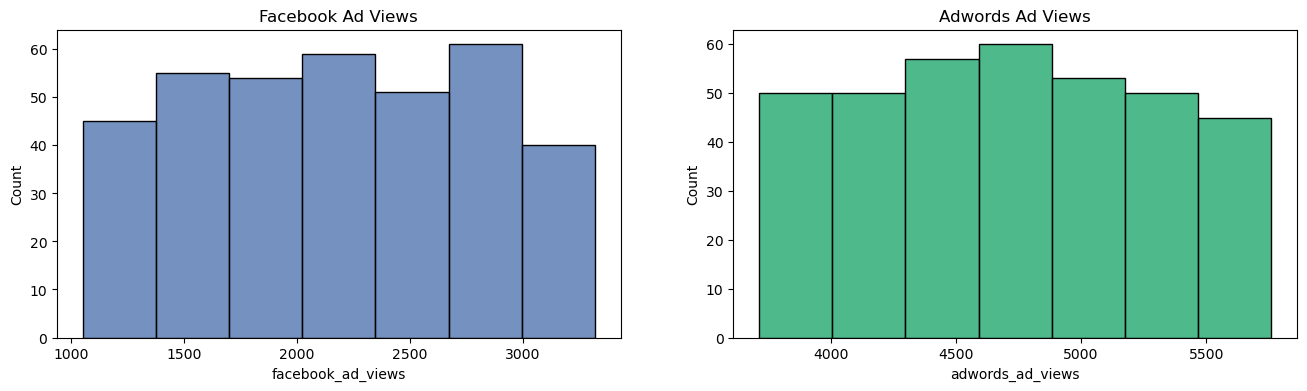

In [9]:
# Number of Ad views and count for facebook and adwords
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Facebook Ad Views')
sns.histplot(data=campaign_data, x='facebook_ad_views', bins=7, color='#456caa')
plt.subplot(1,2,2)
plt.title('Adwords Ad Views')
sns.histplot(data=campaign_data, x='adwords_ad_views', bins=7, color='#13a365')
plt.show()


**The histograms for Ad Views for both campaigns are seen to be uniform. However, the range of number of views differs a lot. The number of views for facebook Ad Campaign ranges approximately between 1000 and 3000, whereas the same for AdWords ranges approximately between 4000 and 5500. This show that AdWords performed better in terms of Ad Views.**

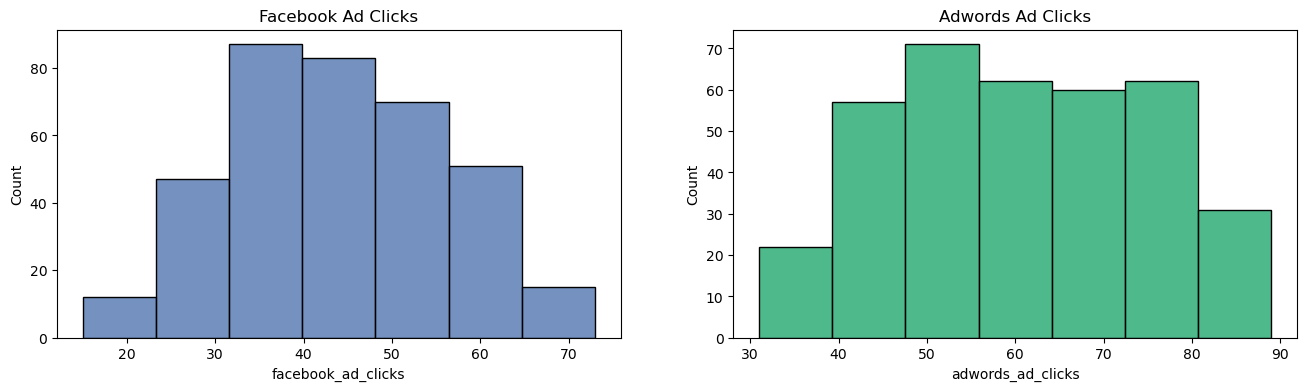

In [10]:
# Number of clicks and count for facebook and adwords
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(data=campaign_data, x='facebook_ad_clicks', bins=7, color='#456caa')
plt.subplot(1,2,2)
plt.title('Adwords Ad Clicks')
sns.histplot(data=campaign_data, x='adwords_ad_clicks', bins=7, color='#13a365')
plt.show()

**The histograms for Ad Clicks are normally distributed and there aren't any outliers. Even though AdWords performed significantly better in terms of number of Ad Views, we see here that the gap has reduced when comparing for number of clicks.**

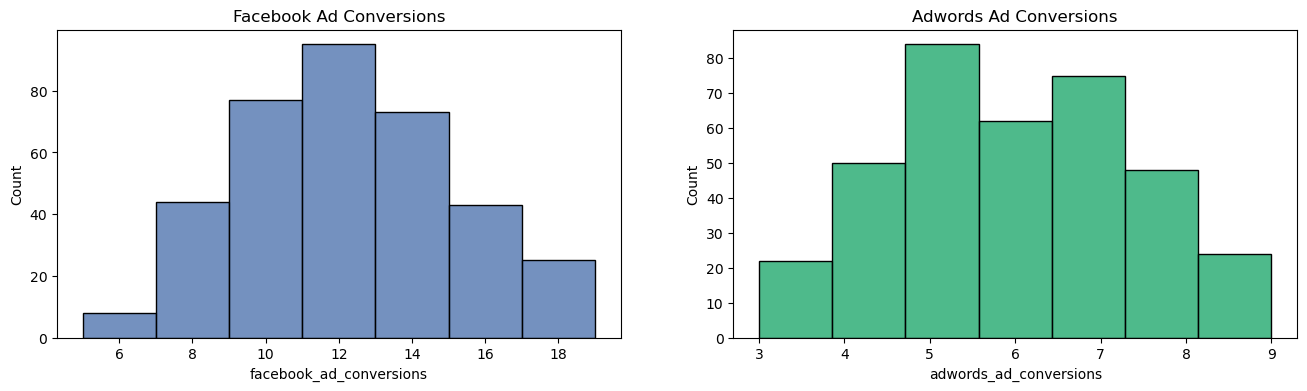

In [11]:
# Number of conversions and count for facebook and adwordss
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Facebook Ad Conversions')
sns.histplot(data=campaign_data, x='facebook_ad_conversions', bins=7, color='#456caa')
plt.subplot(1,2,2)
plt.title('Adwords Ad Conversions')
sns.histplot(data=campaign_data, x='adwords_ad_conversions', bins=7, color='#13a365')
plt.show()

**The distribution for number of conversions is normal and shows the absence of outliers. It is clear that in terms of number of Conversion, Facebook did better than AdWords with a mean of approx 12 conversions per day whereas AdWords has a mean conversion of approximately 6.**

In [34]:
# Comparing mean and median statistics for each field and for each platform

fb_mean = campaign_data[['facebook_ad_views', 'facebook_ad_clicks', 'facebook_ad_conversions', 'cost_per_facebook_ad', 'facebook_click_through_rate', 'facebook_conversion_rate', 'facebook_cost_per_click']].mean().round(2)
fb_med = campaign_data[['facebook_ad_views', 'facebook_ad_clicks', 'facebook_ad_conversions', 'cost_per_facebook_ad', 'facebook_click_through_rate', 'facebook_conversion_rate', 'facebook_cost_per_click']].median().round(2)

ad_mean = campaign_data[['adwords_ad_views', 'adwords_ad_clicks', 'adwords_ad_conversions', 'cost_per_adwords_ad', 'adwords_click_through_rate', 'adwords_conversion_rate', 'adwords_cost_per_click']].mean().round(2)
ad_med = campaign_data[['adwords_ad_views', 'adwords_ad_clicks', 'adwords_ad_conversions', 'cost_per_adwords_ad', 'adwords_click_through_rate', 'adwords_conversion_rate', 'adwords_cost_per_click']].median().round(2)

# Combining Facebook stats
fb_stats = pd.DataFrame({'Mean': fb_mean, 'Median': fb_med})

# Combining Adwords stats
ad_stats = pd.DataFrame({'Mean': ad_mean, 'Median': ad_med})

# Rename index (rows) to match readable labels
fb_stats.index = ['Ad Views', 'Clicks', 'Conversions', 'Cost', 'CTR', 'Conversion Rate', 'CPC']
ad_stats.index = ['Ad Views', 'Clicks', 'Conversions', 'Cost', 'CTR', 'Conversion Rate', 'CPC']

# Combining both into one table
campaign_stats = pd.concat([fb_stats, ad_stats], axis=1, keys=['Facebook', 'Adwords'])
campaign_stats

Facebook           Adwords         
                    Mean   Median     Mean   Median
Ad Views         2179.69  2202.00  4717.20  4711.00
Clicks             44.05    43.00    60.38    60.00
Conversions        11.74    12.00     5.98     6.00
Cost               87.78    88.00   134.98   135.00
CTR                 2.20     2.00     1.30     1.29
Conversion Rate    27.15    26.77    10.18     9.93
CPC                 2.19     2.02     2.38     2.29

## Observations:

Based on the statistics and histogram distribution above:
- AdWords performed better in terms of Ad Views and Clicks.
- Facebook has a significantly better conversion rate at a much lower Cost than AdWords.

**Overall, we have seen that the data for clicks and conversions is normally distributed for both platforms and the distribution for number of views is uniform. There are not many clicks or conversions that are outliers on either the high or low end.**

# Data Transformation

In [35]:
# creating function to calculate the category for number of conversions

def create_conversion_category(conversion_col):
    category = []
    for conversion in campaign_data[conversion_col]:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6 - 10')
        elif 11 <= conversion < 16:
            category.append('10 - 15')
        else:
            category.append('more than 15')
    return category

# applying function of different campaign's conversions
campaign_data['facebook_conversion_category'] = create_conversion_category('facebook_ad_conversions')
campaign_data['adwords_conversion_category'] = create_conversion_category('adwords_ad_conversions')

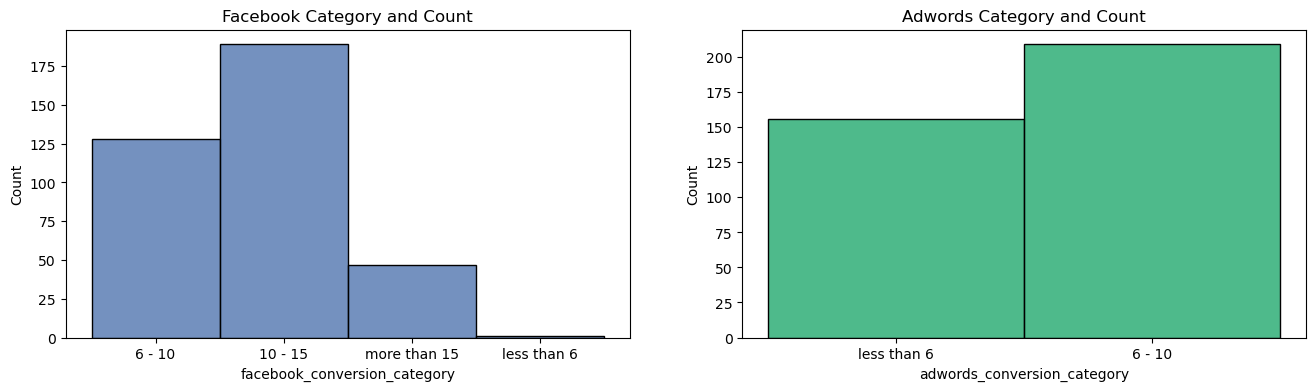

In [36]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Facebook Category and Count')
sns.histplot(data = campaign_data, x = 'facebook_conversion_category', color='#456caa')

plt.subplot(1,2,2)
plt.title('Adwords Category and Count')
sns.histplot(data=campaign_data, x='adwords_conversion_category', color='#13a365')
plt.show()

- **The conversion counts from the facebook campaign has a good majority coming from the 10 to 15 range, with 6 to 10 conversion count category right behind it.**
- **As for AdWords, all the conversion count lies below 10.**

# Saving cleaned and transformed data as CSV

In [14]:
campaign_data.to_csv('cleaned_data.csv', index=False)
print("campaign_data is saved as cleaned_data.csv")

campaign_data is saved as cleaned_data.csv


In [15]:
data =pd.read_csv('cleaned_data.csv')
data.head()

,date,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,cost_per_facebook_ad,facebook_click_through_rate,facebook_conversion_rate,facebook_cost_per_click,adwords_ad_campaign,adwords_ad_views,adwords_ad_clicks,adwords_ad_conversions,cost_per_adwords_ad,adwords_click_through_rate,adwords_conversion_rate,adwords_cost_per_click,facebook_conversion_category,adwords_conversion_category
0,2019-01-01,FB_Jan19,2116,18,8,126.0,0.83,42.73,7.14,AW_Jan19,4984,59,5,194.0,1.18,8.40,3.30,6 - 10,less than 6
1,2019-01-02,FB_Jan19,3106,36,12,104.0,1.15,34.04,2.91,AW_Jan19,4022,71,6,75.0,1.77,7.80,1.05,10 - 15,6 - 10
2,2019-01-03,FB_Jan19,3105,26,8,102.0,0.84,31.45,3.89,AW_Jan19,3863,44,4,141.0,1.13,9.59,3.23,6 - 10,less than 6
3,2019-01-04,FB_Jan19,1107,27,9,71.0,2.45,34.76,2.62,AW_Jan19,3911,49,5,141.0,1.26,11.08,2.86,6 - 10,less than 6
4,2019-01-05,FB_Jan19,1317,15,7,78.0,1.10,47.59,5.38,AW_Jan19,4070,55,7,133.0,1.36,12.22,2.40,6 - 10,6 - 10
